In [1]:
# reload edited modules (e.g. plot_long_gutenberg.py) without restarting the kernel
%load_ext autoreload
%autoreload 2

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from attn_bench.plotting.plot_long_gutenberg import SEQ_LEN

REPS = [0, 1, 2, 4, 8, 16, 32, 64, 128, 256]   # repetition buckets

## Data coverage — how far the Guternberg context reaches

For each position (measured from the sample start), what fraction of sequences still
have a real token there. The sample band `[0, 8190)` is always full; the prefix
extends left (negative) and the suffix right. Dotted lines mark multiples of
`seq_len`.


6,600 rows, 10 buckets: [0, 1, 2, 4, 8, 16, 32, 64, 128, 256]


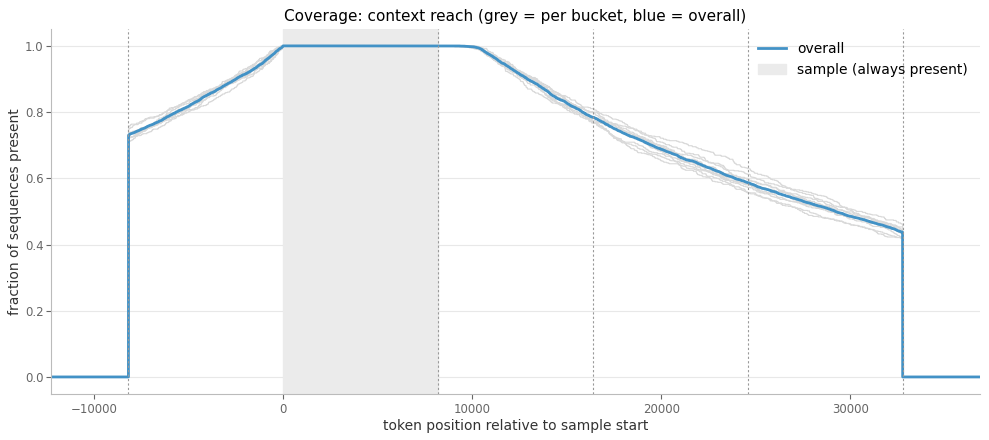

In [2]:
from attn_bench.plotting.plot_long_gutenberg import plot_coverage

# One row per book, per repetition bucket. Transfer this file locally from the cluster.
LENGTHS_PATH = Path("../results/data/gutenberg-long/lengths.jsonl")
df = pd.DataFrame([json.loads(l) for l in LENGTHS_PATH.open()])
BUCKETS = sorted(int(b) for b in df["bucket_rep"].unique())
print(f"{len(df):,} rows, {len(BUCKETS)} buckets: {BUCKETS}")

fig = plot_coverage(df, BUCKETS)
plt.show()

## Position-wise loss past the sample

One cell per repetition bucket: per-position NLL for every model (one colour each). The
dotted line at position 8190 marks where the memorized sample ends and the unseen suffix
begins — attention models are expected to rise there, state-carrying GDN to stay flatter.
The short inverted panel under each cell shows how many sequences still reach each position,
so the thinning tail is visible. `smooth` is a rolling-mean window over position (per-token
NLL is spiky); `show_std=True` shades ±1 std across samples.

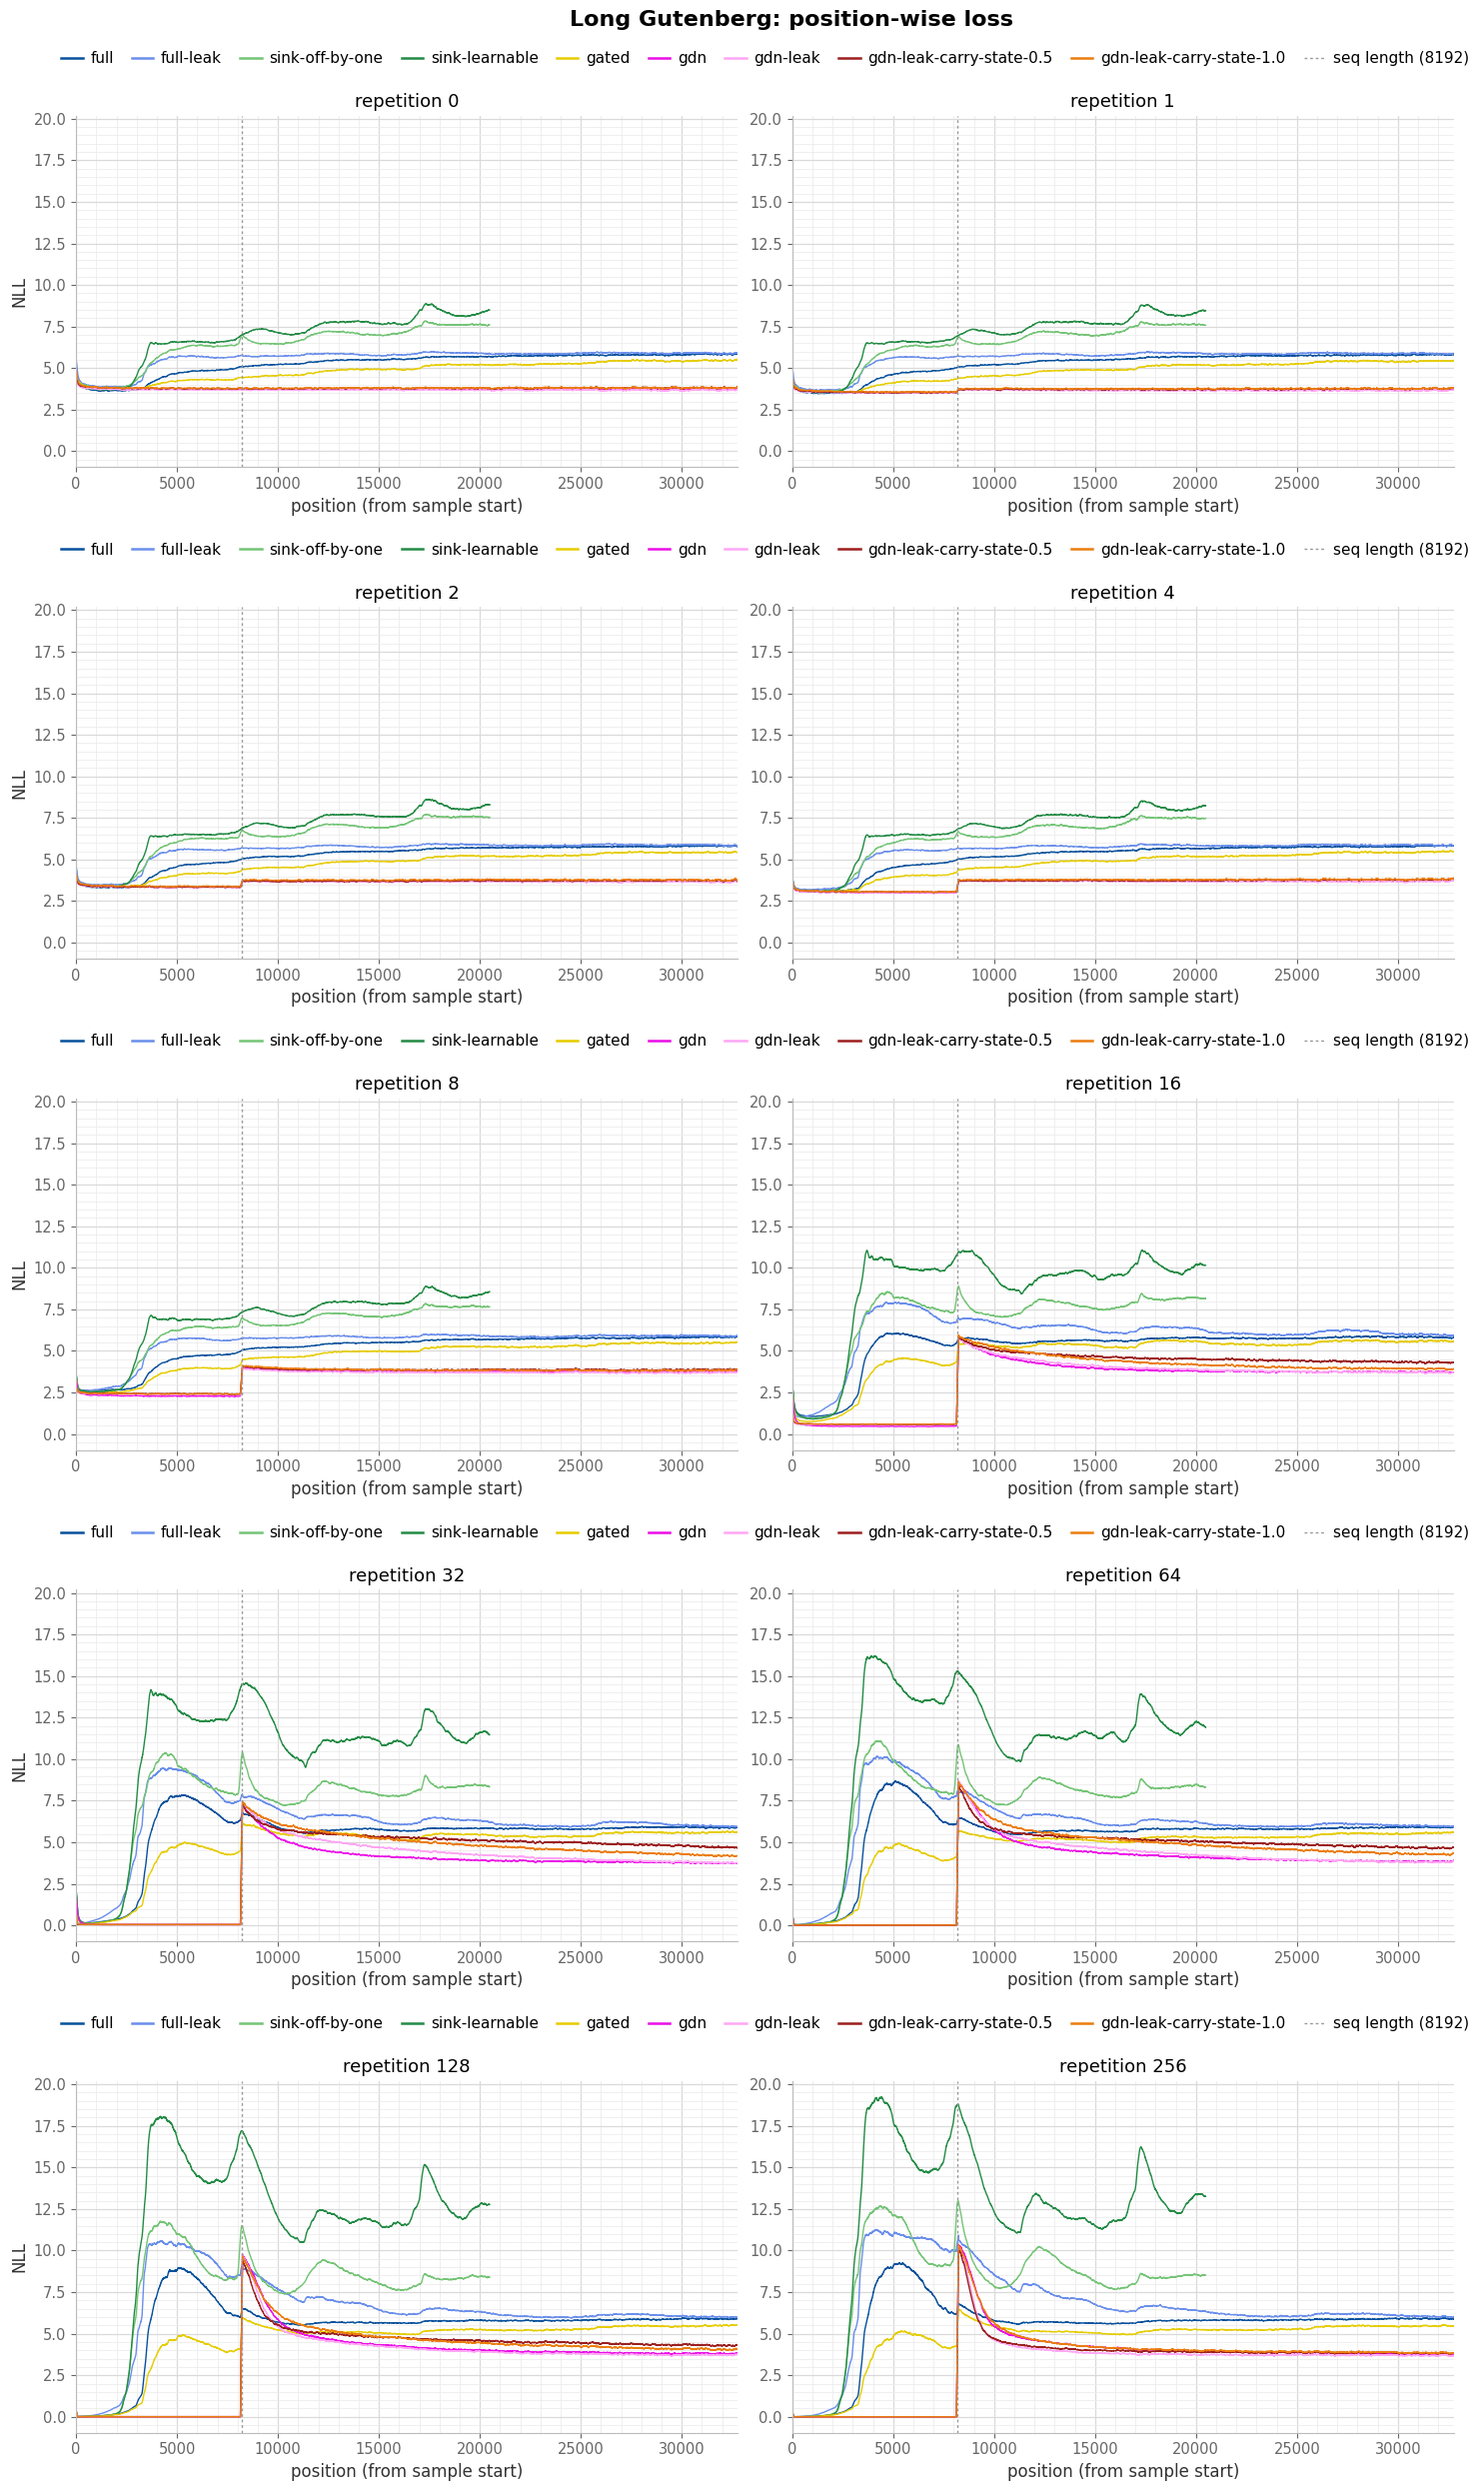

In [37]:
from attn_bench.plotting.plot_long_gutenberg import plot_loss_grid

# Main position-wise loss results on the FULL run (all samples). Fused-attention and GDN
# models use the full-suffix run (up to ~4L); sink / off-by-one OOM there (unfused
# attention), so they use the TP=4 run that reaches 20k instead. One dir per model,
# each holding rep_{R}.npz.
RESULTS_ROOT = Path("../results/long-gutenberg-results")

CONFIG_FULL = "all_samples_full_tokens"        # full suffix, fused attention + GDN
CONFIG_TP4 = "all_samples_20480_tokens_tp4"    # sink / off-by-one: unfused attn OOMs, TP=4 reaches 20k
TP4_MODELS = {"sink-learnable", "sink-off-by-one"}

# Ordered by family so the legend groups the way the plot reads: full-attn, sink, gated, GDN.
MODELS = {
    "full": "llama3-1b-full-attn-fineweb40B-gutenberg3B",
    "full-leak": "llama3-1b-full-attn-xdoc-attn-leak-fineweb40B-gutenberg3B",
    "sink-off-by-one": "llama3-1b-off-by-one-attn-fineweb40B-gutenberg3B-te215",
    "sink-learnable": "llama3-1b-sink-attn-fineweb40B-gutenberg3B-te215",
    "gated": "llama3-1b-gated-attn-fineweb40B-gutenberg3B",
    "gdn": "llama3-1b-gdn-fineweb40B-gutenberg3B",
    "gdn-leak": "llama3-1b-gdn-carry-r0-fineweb40B-gutenberg3B",
    "gdn-leak-carry-state-0.5": "llama3-1b-gdn-carry-r0.5-fineweb40B-gutenberg3B",
    "gdn-leak-carry-state-1.0": "llama3-1b-gdn-carry-r1-fineweb40B-gutenberg3B",
}

# One hue per family, lightness for the variant within it, so "which family" reads at a
# glance. Red / green / purple / blue -- a colourblind-safe set, no black.
COLORS = {
    # full-attention family -- reds
    "full-leak": "#6A8EEB",
    "full":  "#08519c",
    # sink family (softmax-denominator variants) -- greens
    "sink-off-by-one": "#74c476",
    "sink-learnable": "#238b45",
    # gated -- purple
    "gated": "#e6cc00",
    # GDN family -- blues, light (zero state) -> dark (full carry)
    "gdn": "#EB0EE7" ,
    "gdn-leak": "#FFA6F4",
    "gdn-leak-carry-state-0.5": "#9C1F1F",
    # "gdn-leak-carry-state-0.5": "#cb181d",
    "gdn-leak-carry-state-1.0":  "#EB7D0E",
}

results_by_label = {
    lab: RESULTS_ROOT / exp / (CONFIG_TP4 if lab in TP4_MODELS else CONFIG_FULL)
    for lab, exp in MODELS.items()
}

# sharey=True: one common y-scale across all cells so magnitudes are directly comparable
# across reps (low-rep cells look compressed because sink's high-rep suffix sets the top).
# xmax=4L: GDN/full reach ~32k; sink/off-by-one stop at ~20k and their lines just end there.
fig = plot_loss_grid(results_by_label, reps=REPS, ncols=2, smooth=100, xmax=4 * SEQ_LEN,
                     show_std=False, sharey=True,
                     suptitle="Long Gutenberg: position-wise loss", colors=COLORS)
plt.show()

## GDN state norm along the sequence

One cell per repetition bucket: the Frobenius norm of each GDN recurrent state, averaged over
all layers and heads, against token position. Only the four GDN variants carry a state, so the
attention baselines drop out here. The dotted line at 8192 marks the training sequence length;
boundaries past it are extrapolation (capped by `xmax`, which defaults to 8192). `show_std=True`
would shade ±1 std across layers/heads, but that spread is large enough to hide the differences
between models, so it is off in this overview.

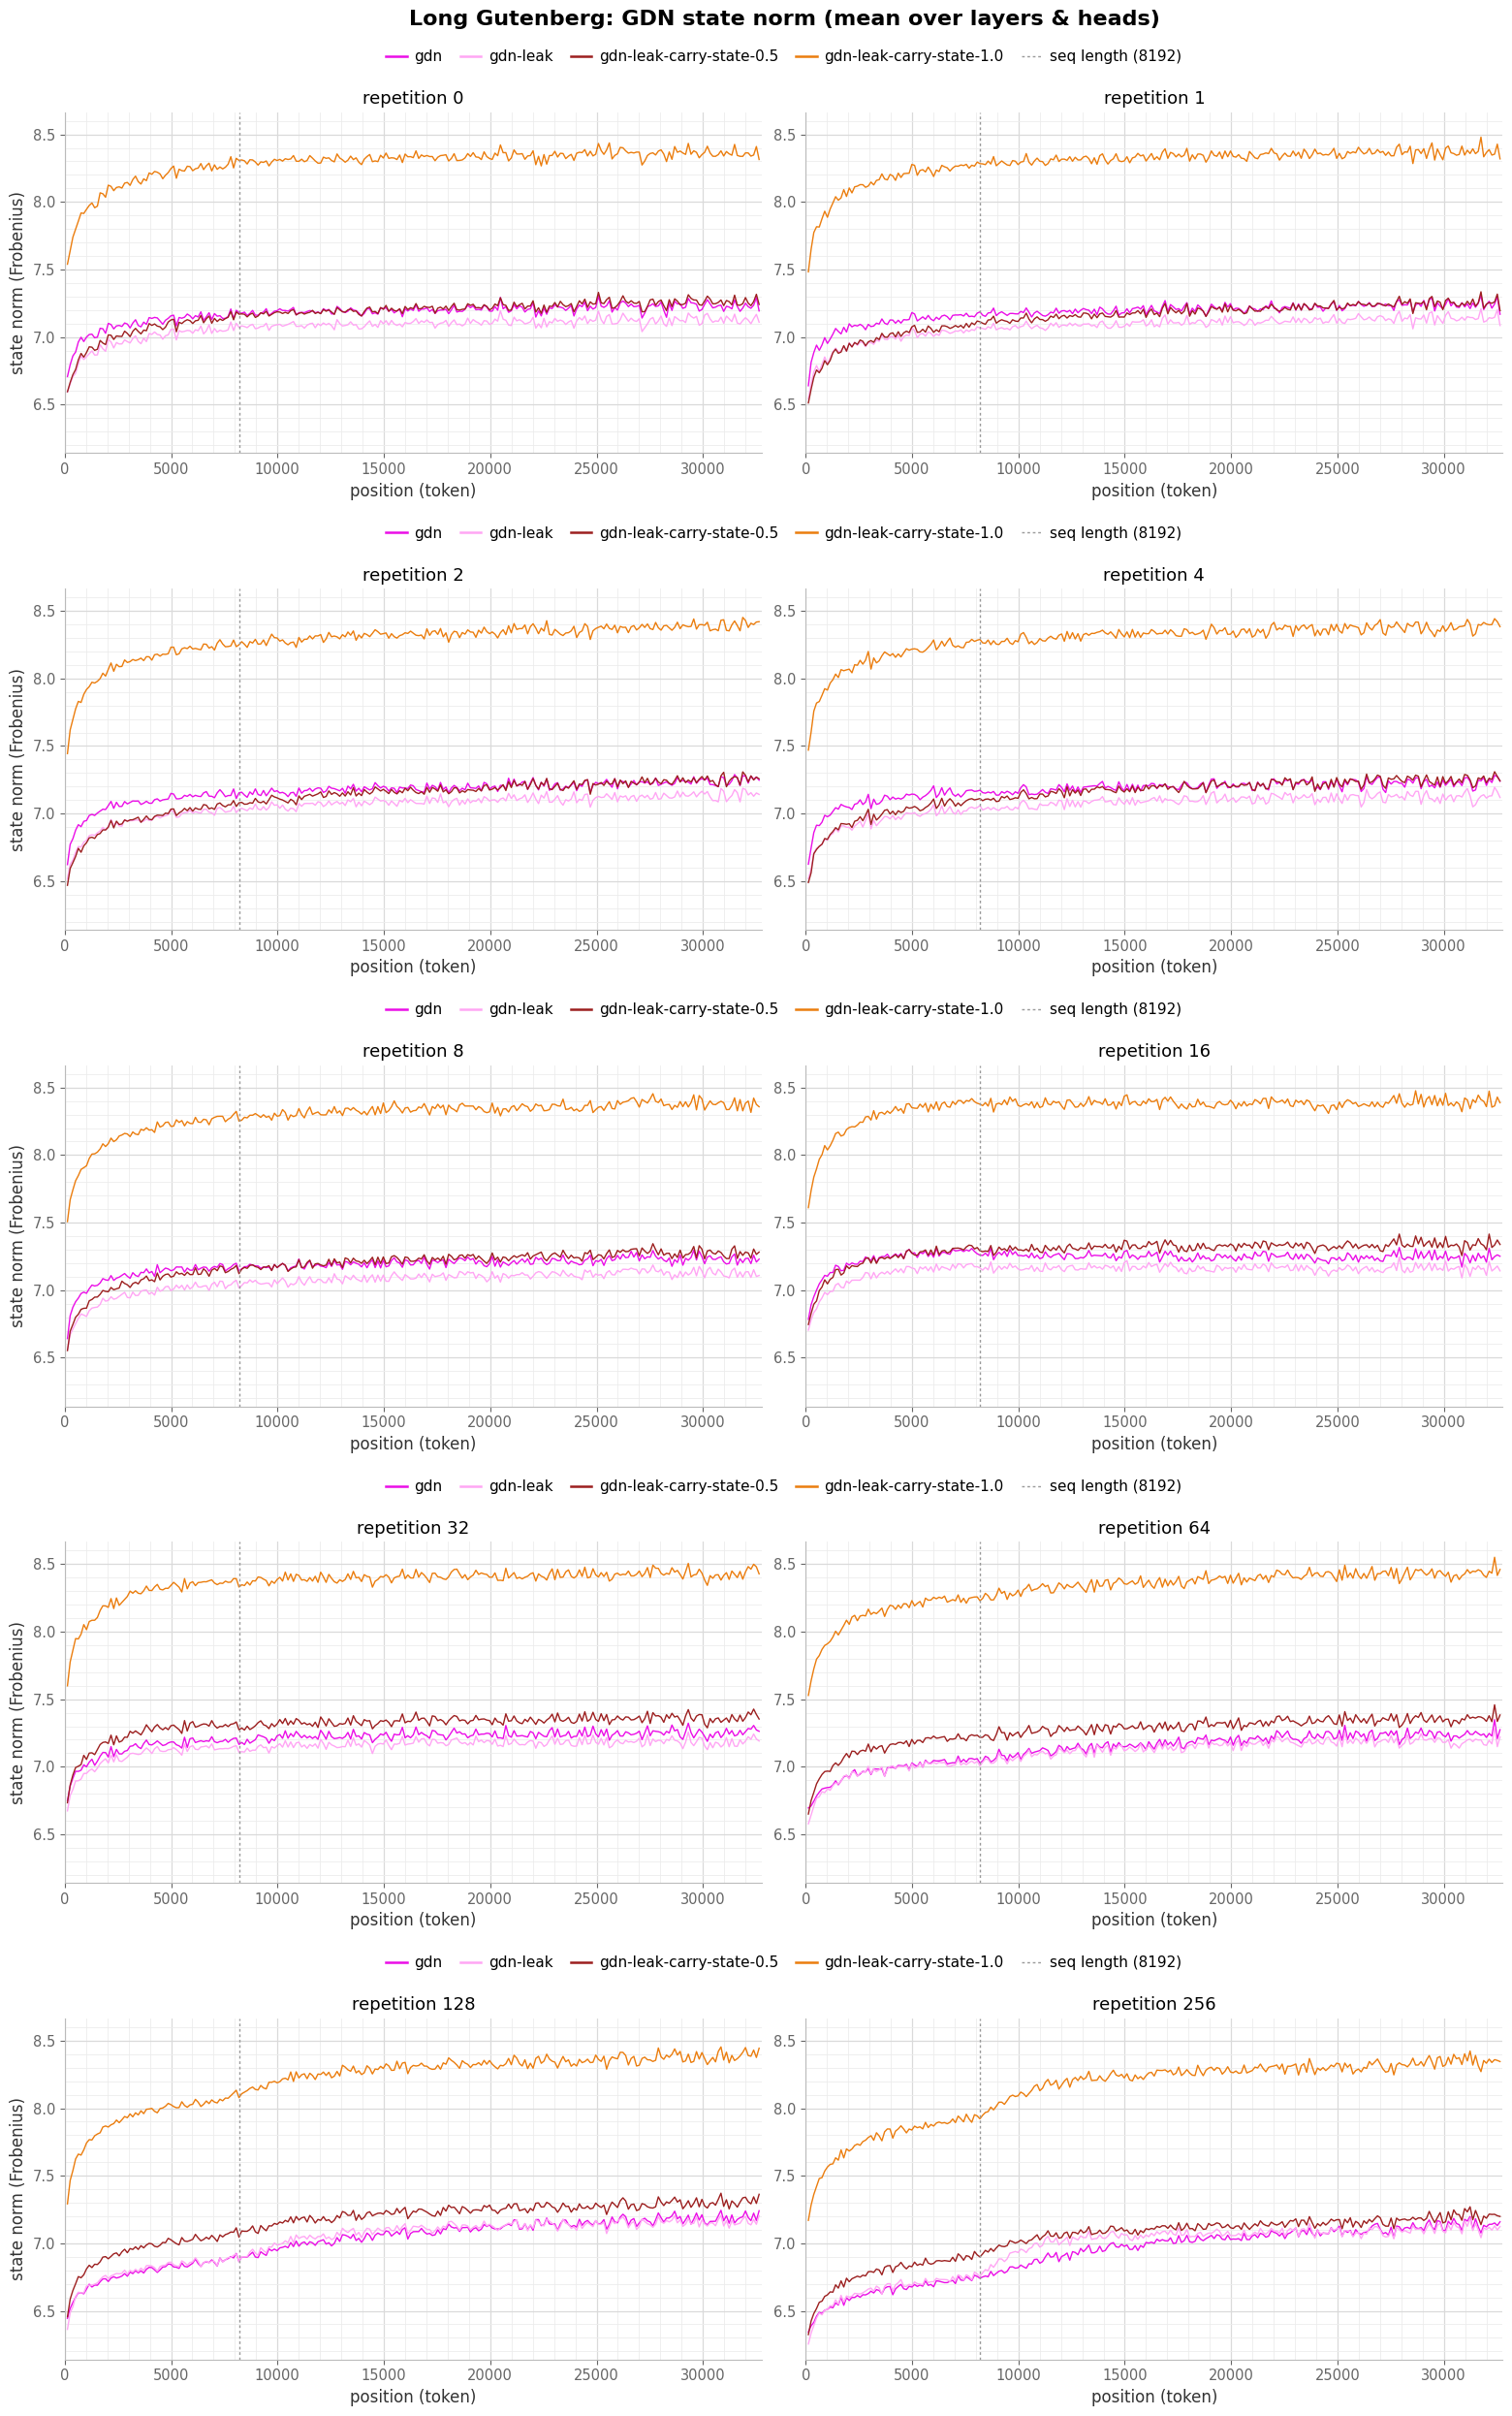

In [38]:
from attn_bench.plotting.plot_long_gutenberg import plot_state_norm_grid

# Only the four GDN variants carry a recurrent state. Reuse the same labels/colours as the
# loss plot so the GDN family lines up across figures; each dir also holds rep_{R}_state.npz.
GDN_MODELS = ["gdn", "gdn-leak", "gdn-leak-carry-state-0.5", "gdn-leak-carry-state-1.0"]
state_by_label = {lab: results_by_label[lab] for lab in GDN_MODELS}

# xmax defaults to the training length (8192); boundaries run further (~32k) but thin out.
# show_std=False: the spread across layers/heads swamps the model differences (that belongs
# in the per-layer breakdown, not this collapsed overview). The norms are already averaged
# over many samples, so no smoothing is needed.
fig = plot_state_norm_grid(state_by_label, reps=REPS, ncols=2, smooth=0, xmax=4 * SEQ_LEN,
                           show_std=False, sharey=True,
                           suptitle="Long Gutenberg: GDN state norm (mean over layers & heads)",
                           colors={lab: COLORS[lab] for lab in GDN_MODELS})
plt.show()

## GDN state norm by layer

For a single repetition bucket (`REP`), one subplot per GDN model with the 16 head-averaged
layer norms as separate lines, coloured from layer 1 (dark) to layer 16 (bright). This is the
per-layer breakdown of the collapsed overview above — it shows which layers carry the large
norms and the wide across-layer spread the overview's ±std would have shown.

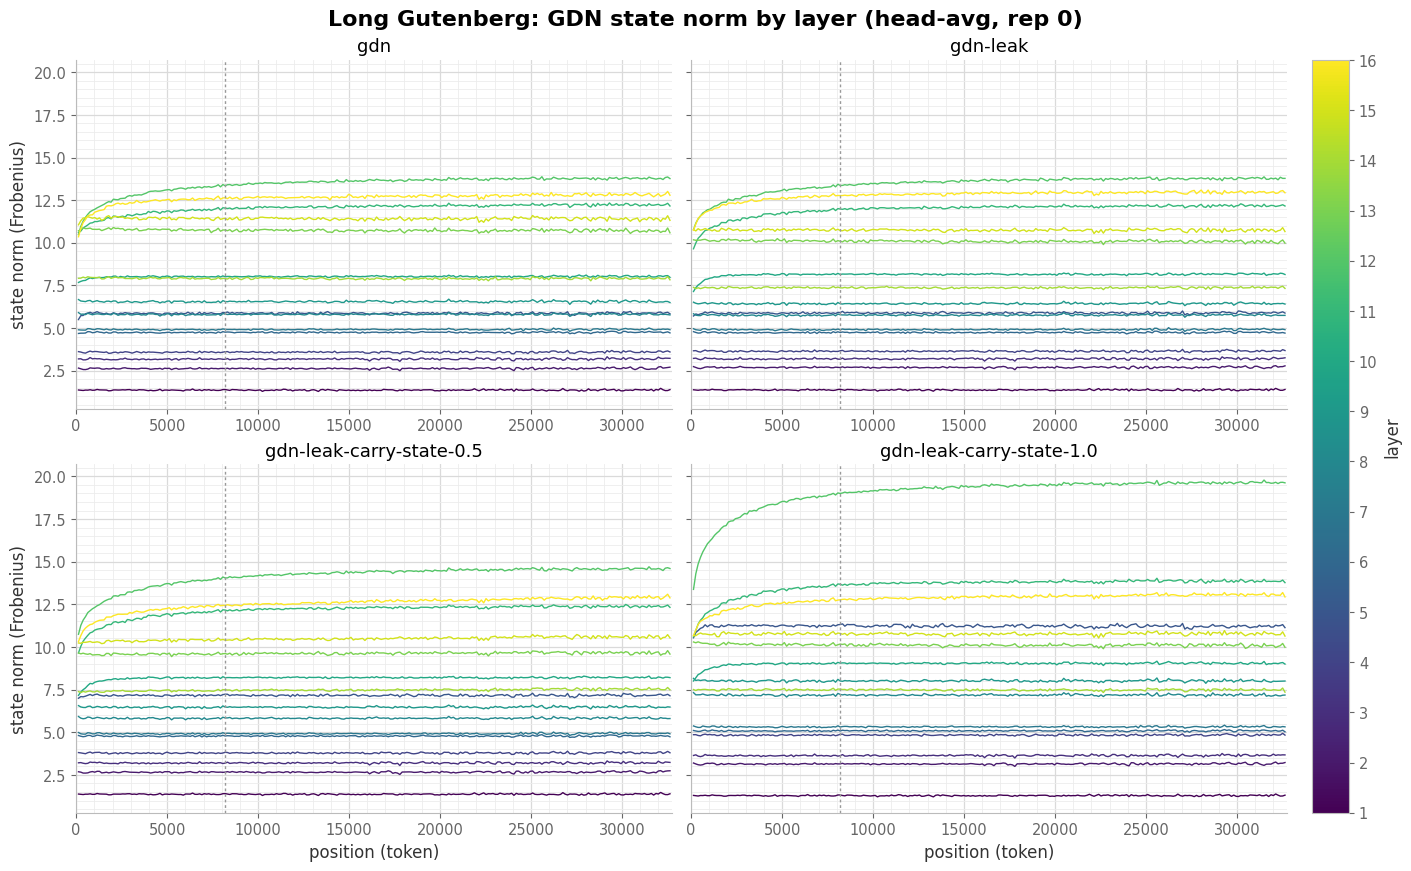

In [44]:
from attn_bench.plotting.plot_long_gutenberg import plot_state_norm_by_layer

# Break the overview down: one subplot per GDN model for a single rep, 16 head-averaged layer
# lines each, coloured from layer 1 (dark) to 16 (bright). REP picks the bucket; re-run with a
# different value to compare. Reuses state_by_label (the four GDN dirs) from the cell above.
REP = 0
fig = plot_state_norm_by_layer(state_by_label, rep=REP, xmax=4 * SEQ_LEN,
                               suptitle=f"Long Gutenberg: GDN state norm by layer (head-avg, rep {REP})")
plt.show()

## TP=1 vs TP=4 — does tensor parallelism change the numbers?

For sink / off-by-one only. The TP=1 run (data-parallel, unfused attention, capped at
12k because it OOMs past ~12k) against the TP=4 run (heads sharded over 4 GPUs, reaches
20k). Tensor parallelism shouldn't change the math, so in the shared 0..12k region the
two lines should sit on top of each other. One figure per model, one cell per repetition.

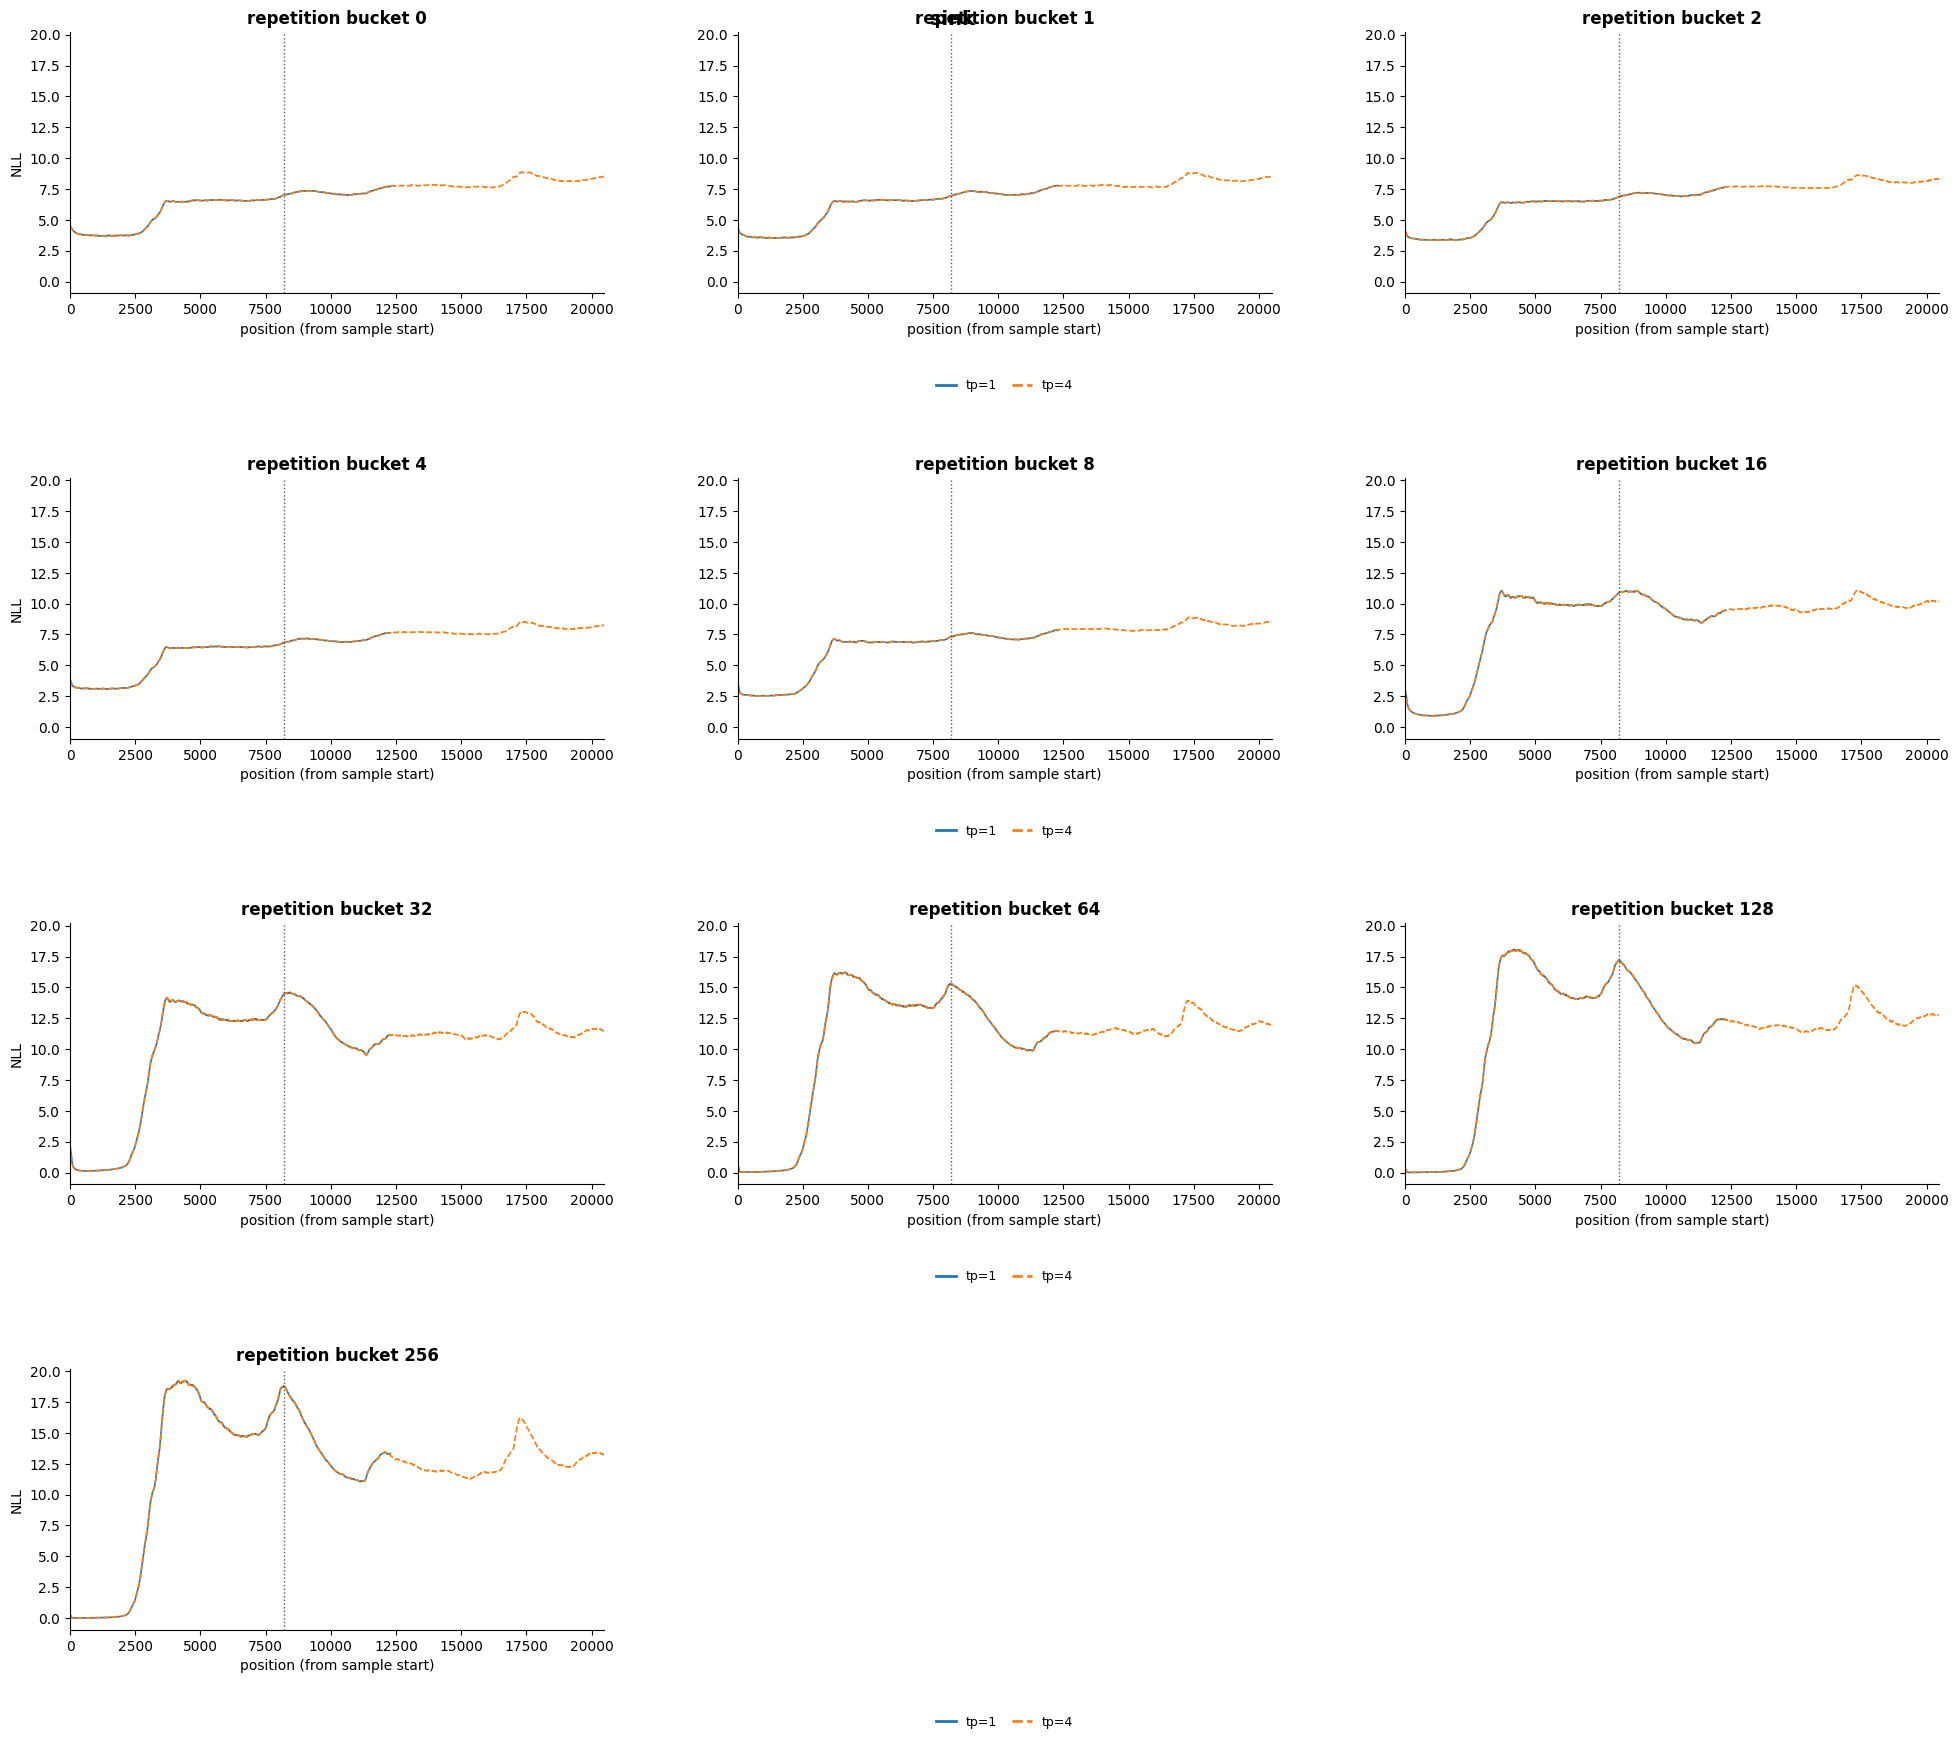

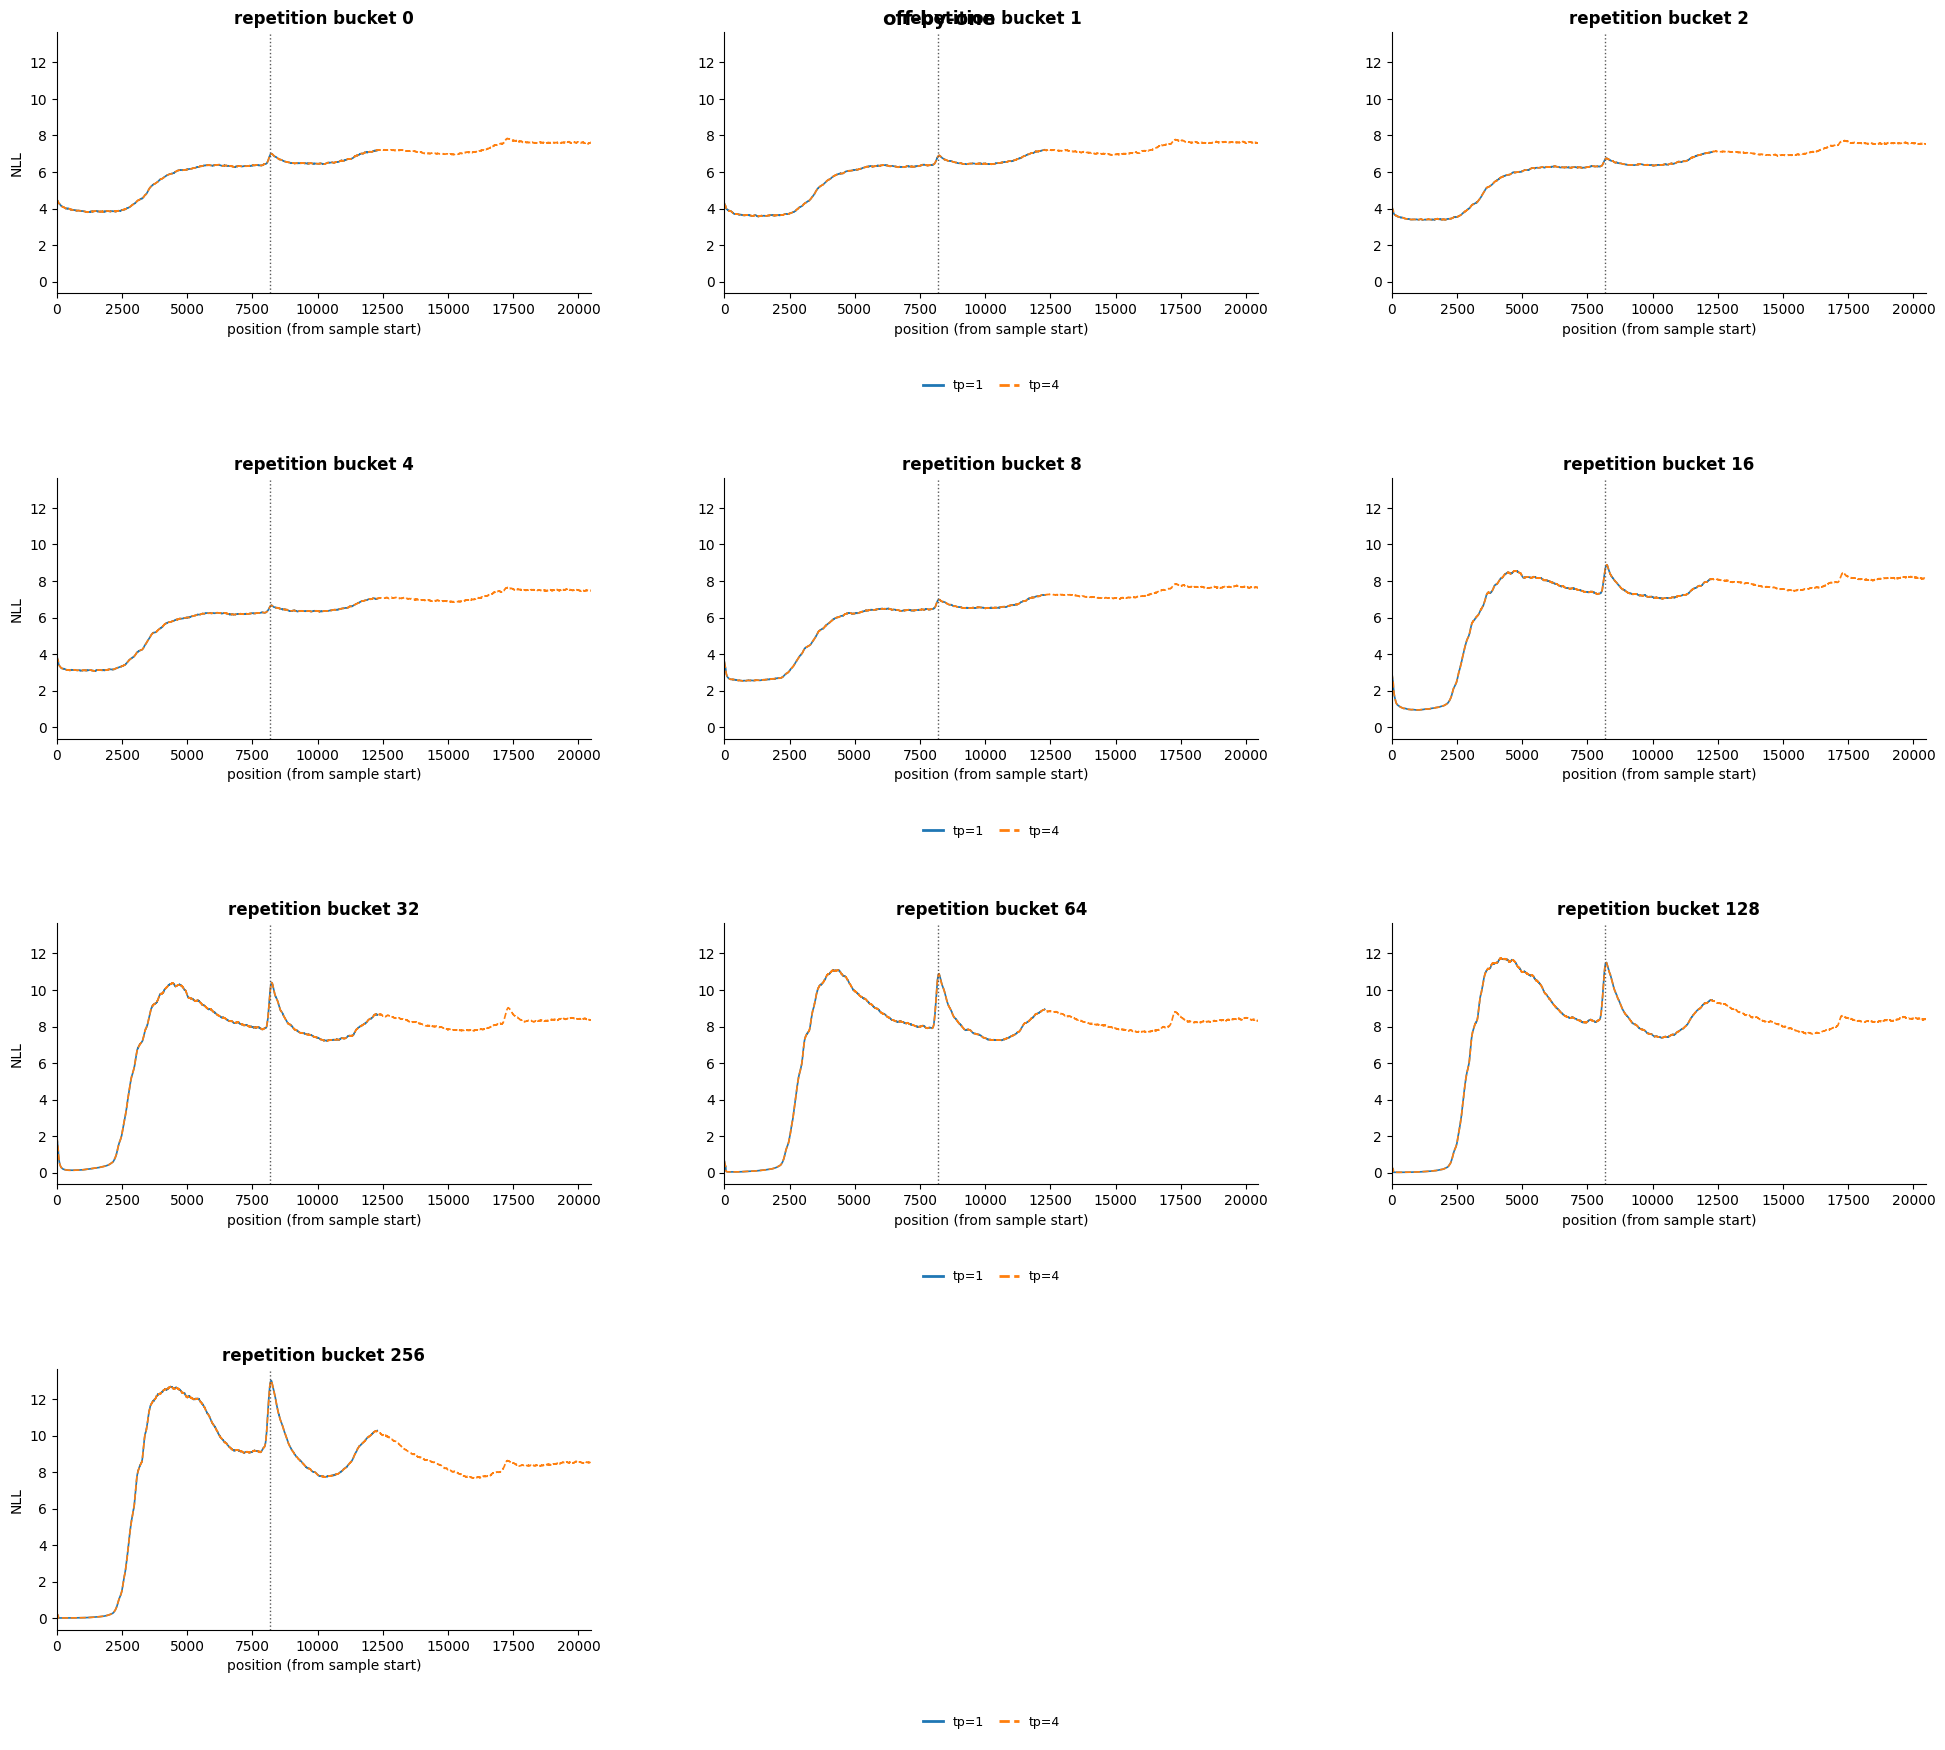

In [16]:
# tp=1 -> the 12k-capped DP run; tp=4 -> the 20k tensor-parallel run.
TP1_CONFIG = "all_samples_12288_tokens"       # DP, TP=1
TP4_CONFIG = "all_samples_20480_tokens_tp4"   # 4-way tensor parallel

for lab in ("sink", "off-by-one"):
    exp = MODELS[lab]
    tp_dirs = {
        "tp=1": RESULTS_ROOT / exp / TP1_CONFIG,
        "tp=4": RESULTS_ROOT / exp / TP4_CONFIG,
    }
    fig = plot_loss_grid(tp_dirs, reps=REPS, smooth=100, xmax=20480, show_std=False,
                         linestyles={"tp=1": "-", "tp=4": "--"}, suptitle=lab)
    plt.show()

In [12]:
from attn_bench.plotting.plot_long_gutenberg import load_nll, _rep_path

# Put a number on the gap the plots show by eye. Over the positions present in BOTH
# runs (tp=1 stops ~12k, tp=4 reaches 20k) compare the per-position mean NLL. Report the
# absolute difference (max and mean) and the same as a percentage of the region's average
# NLL, so the size is readable -- 0.05 nats means nothing without the loss scale. Tensor
# parallelism only reorders the reductions, so this should stay small, not a real change.
REL_TOL = 0.01   # flag if the mean difference exceeds 1% of the typical loss

for lab in ("sink", "off-by-one"):
    exp = MODELS[lab]
    d1 = RESULTS_ROOT / exp / TP1_CONFIG
    d4 = RESULTS_ROOT / exp / TP4_CONFIG
    print(lab)
    print(f"  {'rep':>4}  {'shared_pos':>10}  {'max_abs':>8}  {'max_%':>7}  {'mean_abs':>9}  {'mean_%':>7}")
    worst_rel = 0.0
    for rep in REPS:
        p1, p4 = _rep_path(d1, rep), _rep_path(d4, rep)
        if not (p1.exists() and p4.exists()):
            continue
        a, b = load_nll(p1), load_nll(p4)
        # intersect on shared positions; both position arrays are sorted ascending
        common, i1, i4 = np.intersect1d(a["position"], b["position"], return_indices=True)
        ma, mb = a["mean"][i1], b["mean"][i4]
        diff = np.abs(ma - mb)
        ref = 0.5 * (ma + mb).mean()   # region-average NLL: the scale to judge the diff against
        max_rel, mean_rel = diff.max() / ref, diff.mean() / ref
        worst_rel = max(worst_rel, mean_rel)
        print(f"  {rep:>4}  {len(common):>10}  {diff.max():>8.2e}  {100*max_rel:>6.2f}%  {diff.mean():>9.2e}  {100*mean_rel:>6.2f}%")
    flag = "OK" if worst_rel < REL_TOL else f"CHECK (> {100*REL_TOL:g}%)"
    print(f"  worst mean diff over all reps: {100*worst_rel:.2f}% of typical loss  [{flag}]\n")

sink
   rep  shared_pos   max_abs    max_%   mean_abs   mean_%
     0       12287  1.22e-02    0.20%   2.13e-03    0.04%
     1       12287  1.19e-02    0.20%   2.11e-03    0.03%
     2       12287  1.13e-02    0.19%   2.04e-03    0.03%
     4       12287  9.91e-03    0.17%   2.04e-03    0.03%
     8       12287  1.48e-02    0.25%   2.57e-03    0.04%
    16       12287  3.37e-02    0.43%   5.41e-03    0.07%
    32       12287  5.63e-02    0.59%   6.74e-03    0.07%
  worst mean diff over all reps: 0.07% of typical loss  [OK]

off-by-one
   rep  shared_pos   max_abs    max_%   mean_abs   mean_%
     0       12287  1.24e-02    0.22%   2.24e-03    0.04%
     1       12287  1.05e-02    0.19%   2.12e-03    0.04%
     2       12287  9.98e-03    0.18%   2.08e-03    0.04%
     4       12287  1.14e-02    0.21%   1.99e-03    0.04%
     8       12287  1.31e-02    0.24%   2.32e-03    0.04%
    16       12287  2.91e-02    0.47%   4.22e-03    0.07%
    32       12287  4.35e-02    0.66%   5.14e-03    